# German Credit 数据集全量变量分箱对比实验

本 Notebook 对 `germancredit.csv` 数据集的**所有变量**进行分箱，对比 `scorecard` 模块和 `scorecard_legacy` 模块的分箱结果。

## 数据集说明
- germancredit.csv 是德国信用数据集
- 目标变量：creditability (good=好客户, bad=坏客户)
- **预处理**：将 creditability 转换为 0/1 变量 (good→0, bad→1)
- 特征：20 个变量，包含数值型和类别型
- 样本量：1000 条记录

In [1]:
# 设置内核为 conda py311 环境
# 请确保在 Jupyter 中选择正确的内核: Python (py311)

In [2]:
import sys
import warnings
warnings.filterwarnings('ignore')

# 添加项目路径
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import time
from IPython.display import display, HTML

print(f"Python 版本: {sys.version}")
print(f"Pandas 版本: {pd.__version__}")
print(f"NumPy 版本: {np.__version__}")

Python 版本: 3.11.14 | packaged by conda-forge | (main, Oct 22 2025, 22:56:31) [Clang 19.1.7 ]
Pandas 版本: 3.0.1
NumPy 版本: 1.26.0


## 1. 加载数据

In [3]:
# 加载 germancredit 数据集
df = pd.read_csv('../data/germancredit.csv.gz')
print(f"数据集形状: {df.shape}")
print(f"\n原始目标变量分布:")
print(df['creditability'].value_counts())

# 将 creditability 转换为 0/1 变量
# good -> 0 (好客户), bad -> 1 (坏客户)
df['creditability'] = (df['creditability'] == 'bad').astype(int)
print(f"\n转换后目标变量分布:")
print(df['creditability'].value_counts())
print(f"\n坏率: {df['creditability'].mean():.4%}")

数据集形状: (1000, 21)

原始目标变量分布:
creditability
good    700
bad     300
Name: count, dtype: int64

转换后目标变量分布:
creditability
0    700
1    300
Name: count, dtype: int64

坏率: 30.0000%


In [4]:
# 确定所有特征变量
target = 'creditability'
all_features = [col for col in df.columns if col != target]

print(f"目标变量: {target}")
print(f"特征数量: {len(all_features)}")
print(f"\n特征列表:")
for i, feat in enumerate(all_features, 1):
    print(f"  {i:2d}. {feat}")

目标变量: creditability
特征数量: 20

特征列表:
   1. status.of.existing.checking.account
   2. duration.in.month
   3. credit.history
   4. purpose
   5. credit.amount
   6. savings.account.and.bonds
   7. present.employment.since
   8. installment.rate.in.percentage.of.disposable.income
   9. personal.status.and.sex
  10. other.debtors.or.guarantors
  11. present.residence.since
  12. property
  13. age.in.years
  14. other.installment.plans
  15. housing
  16. number.of.existing.credits.at.this.bank
  17. job
  18. number.of.people.being.liable.to.provide.maintenance.for
  19. telephone
  20. foreign.worker


In [5]:
# 变量类型分析
print("变量类型分析:")
print("\n数值型变量:")
numeric_vars = df[all_features].select_dtypes(include=[np.number]).columns.tolist()
for v in numeric_vars:
    print(f"  - {v}: unique={df[v].nunique()}, min={df[v].min()}, max={df[v].max()}")

print("\n类别型变量:")
categorical_vars = df[all_features].select_dtypes(exclude=[np.number]).columns.tolist()
for v in categorical_vars:
    print(f"  - {v}: unique={df[v].nunique()}")

变量类型分析:

数值型变量:
  - duration.in.month: unique=33, min=4, max=72
  - credit.amount: unique=921, min=250, max=18424
  - installment.rate.in.percentage.of.disposable.income: unique=4, min=1, max=4
  - present.residence.since: unique=4, min=1, max=4
  - age.in.years: unique=53, min=19, max=75
  - number.of.existing.credits.at.this.bank: unique=4, min=1, max=4
  - number.of.people.being.liable.to.provide.maintenance.for: unique=2, min=1, max=2

类别型变量:
  - status.of.existing.checking.account: unique=4
  - credit.history: unique=5
  - purpose: unique=10
  - savings.account.and.bonds: unique=5
  - present.employment.since: unique=5
  - personal.status.and.sex: unique=4
  - other.debtors.or.guarantors: unique=3
  - property: unique=4
  - other.installment.plans: unique=3
  - housing: unique=3
  - job: unique=4
  - telephone: unique=2
  - foreign.worker: unique=2


In [6]:
# 预览数据
df.head(10)

,status.of.existing.checking.account,duration.in.month,credit.history,purpose,credit.amount,savings.account.and.bonds,present.employment.since,installment.rate.in.percentage.of.disposable.income,personal.status.and.sex,other.debtors.or.guarantors,...,property,age.in.years,other.installment.plans,housing,number.of.existing.credits.at.this.bank,job,number.of.people.being.liable.to.provide.maintenance.for,telephone,foreign.worker,creditability
0,... < 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,... >= 7 years,4,male : divorced/separated,none,...,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,0
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,radio/television,5951,... < 100 DM,1 <= ... < 4 years,2,male : divorced/separated,none,...,real estate,22,none,own,1,skilled employee / official,1,none,yes,1
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,... < 100 DM,4 <= ... < 7 years,2,male : divorced/separated,none,...,real estate,49,none,own,1,unskilled - resident,2,none,yes,0
3,... < 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,... < 100 DM,4 <= ... < 7 years,2,male : divorced/separated,guarantor,...,building society savings agreement/ life insur...,45,none,for free,1,skilled employee / official,2,none,yes,0
4,... < 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : divorced/separated,none,...,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes,1
5,no checking account,36,existing credits paid back duly till now,education,9055,unknown/ no savings account,1 <= ... < 4 years,2,male : divorced/separated,none,...,unknown / no property,35,none,for free,1,unskilled - resident,2,"yes, registered under the customers name",yes,0
6,no checking account,24,existing credits paid back duly till now,furniture/equipment,2835,500 <= ... < 1000 DM,... >= 7 years,3,male : divorced/separated,none,...,building society savings agreement/ life insur...,53,none,own,1,skilled employee / official,1,none,yes,0
7,0 <= ... < 200 DM,36,existing credits paid back duly till now,car (used),6948,... < 100 DM,1 <= ... < 4 years,2,male : divorced/separated,none,...,"car or other, not in attribute Savings account...",35,none,rent,1,management/ self-employed/ highly qualified em...,1,"yes, registered under the customers name",yes,0
8,no checking account,12,existing credits paid back duly till now,radio/television,3059,... >= 1000 DM,4 <= ... < 7 years,2,male : divorced/separated,none,...,real estate,61,none,own,1,unskilled - resident,1,none,yes,0
9,0 <= ... < 200 DM,30,critical account/ other credits existing (not ...,car (new),5234,... < 100 DM,unemployed,4,male : divorced/separated,none,...,"car or other, not in attribute Savings account...",28,none,own,2,management/ self-employed/ highly qualified em...,1,none,yes,1


## 2. 使用 scorecard_legacy 模块进行分箱

In [7]:
from syriskmodels.scorecard_legacy import woebin as woebin_legacy
from syriskmodels.scorecard_legacy import sc_bins_to_df as sc_bins_to_df_legacy

In [8]:
%%time
# 使用 scorecard_legacy 进行分箱
# 默认方法: quantile + tree
# 注意: creditability 已转换为 0/1，1=坏客户
print("开始 scorecard_legacy 分箱...")
start_time = time.time()

bins_legacy = woebin_legacy(
    df, 
    y=target, 
    x=all_features,
    methods=['quantile', 'tree'],
    positive=1,  # 坏样本标识为 1
    no_cores=1  # 数据量小，单进程即可
)

legacy_time = time.time() - start_time
print(f"\nscorecard_legacy 分箱耗时: {legacy_time:.2f} 秒")

开始 scorecard_legacy 分箱...

scorecard_legacy 分箱耗时: 1.14 秒
CPU times: user 1.12 s, sys: 8.26 ms, total: 1.13 s
Wall time: 1.14 s


In [9]:
# 查看分箱结果
woe_df_legacy, iv_df_legacy = sc_bins_to_df_legacy(bins_legacy)
print("=== scorecard_legacy 分箱结果 ===")
print(f"\n成功分箱变量数: {len([v for v in bins_legacy if isinstance(bins_legacy[v], pd.DataFrame)])}")
print(f"\nIV 汇总表 (按 IV 降序):")
display(iv_df_legacy)

=== scorecard_legacy 分箱结果 ===

成功分箱变量数: 20

IV 汇总表 (按 IV 降序):


,IV,IV区间,单调性,最大Lift,最小Lift
variable,,,,,
status.of.existing.checking.account,0.639372,"[0.2, +)",decreasing,1.473297,0.389171
credit.history,0.291829,"[0.2, +)",decreasing,1.985019,0.568828
duration.in.month,0.263943,"[0.2, +)",increasing,1.607843,0.354610
savings.account.and.bonds,0.189391,"[0.1, 0.2)",decreasing,1.185080,0.555556
credit.amount,0.171426,"[0.1, 0.2)",non_monotonic,1.933333,0.633333
purpose,0.163406,"[0.1, 0.2)",decreasing,1.299790,0.535714
age.in.years,0.123935,"[0.1, 0.2)",up_u_shape,1.403509,0.506329
property,0.112634,"[0.1, 0.2)",decreasing,1.450216,0.709220
housing,0.082951,"[0.08, 0.1)",decreasing,1.324042,0.869565


## 3. 使用 scorecard 模块进行分箱

In [10]:
from syriskmodels.scorecard import woebin as woebin_new
from syriskmodels.scorecard import sc_bins_to_df as sc_bins_to_df_new

In [11]:
%%time
# 使用 scorecard 模块进行分箱
# 相同的参数设置
print("开始 scorecard 模块分箱...")
start_time = time.time()

bins_new = woebin_new(
    df, 
    y=target, 
    x=all_features,
    methods=['quantile', 'tree'],
    positive=1,  # 坏样本标识为 1
    no_cores=1
)

new_time = time.time() - start_time
print(f"\nscorecard 模块分箱耗时: {new_time:.2f} 秒")

开始 scorecard 模块分箱...

scorecard 模块分箱耗时: 1.35 秒
CPU times: user 1.22 s, sys: 14.6 ms, total: 1.24 s
Wall time: 1.35 s


In [12]:
# 查看分箱结果
woe_df_new, iv_df_new = sc_bins_to_df_new(bins_new)
print("=== scorecard 模块分箱结果 ===")
print(f"\n成功分箱变量数: {len([v for v in bins_new if isinstance(bins_new[v], pd.DataFrame)])}")
print(f"\nIV 汇总表 (按 IV 降序):")
display(iv_df_new)

=== scorecard 模块分箱结果 ===

成功分箱变量数: 20

IV 汇总表 (按 IV 降序):


,IV,IV区间,单调性,最大Lift,最小Lift
variable,,,,,
status.of.existing.checking.account,0.639372,"[0.2, +)",decreasing,1.473297,0.389171
credit.history,0.291829,"[0.2, +)",decreasing,1.985019,0.568828
duration.in.month,0.263943,"[0.2, +)",increasing,1.607843,0.354610
savings.account.and.bonds,0.189391,"[0.1, 0.2)",decreasing,1.185080,0.555556
credit.amount,0.171426,"[0.1, 0.2)",non_monotonic,1.933333,0.633333
purpose,0.163406,"[0.1, 0.2)",decreasing,1.299790,0.535714
age.in.years,0.123935,"[0.1, 0.2)",up_u_shape,1.403509,0.506329
property,0.112634,"[0.1, 0.2)",decreasing,1.450216,0.709220
housing,0.082951,"[0.08, 0.1)",decreasing,1.324042,0.869565


## 4. 分箱结果全面对比

### 4.1 性能对比

In [13]:
print("="*60)
print("性能对比")
print("="*60)
print(f"\nscorecard_legacy 耗时: {legacy_time:.2f} 秒")
print(f"scorecard 模块耗时:   {new_time:.2f} 秒")
print(f"\n性能差异: {(new_time - legacy_time):.2f} 秒 ({(new_time/legacy_time - 1)*100:+.1f}%)")

性能对比

scorecard_legacy 耗时: 1.14 秒
scorecard 模块耗时:   1.35 秒

性能差异: 0.21 秒 (+18.2%)


### 4.2 IV 值对比

In [14]:
# IV 值对比
iv_compare = pd.DataFrame({
    'variable': iv_df_legacy.index,
    'IV_legacy': iv_df_legacy['IV'].values,
    'IV_new': iv_df_new['IV'].values,
})
iv_compare['IV_diff'] = (iv_compare['IV_new'] - iv_compare['IV_legacy']).abs()
iv_compare['IV_diff_pct'] = np.where(
    iv_compare['IV_legacy'] > 0,
    iv_compare['IV_diff'] / iv_compare['IV_legacy'] * 100,
    0
)

print("IV 值对比 (按 legacy IV 降序):")
display(iv_compare.round(6))

IV 值对比 (按 legacy IV 降序):


,variable,IV_legacy,IV_new,IV_diff,IV_diff_pct
0,status.of.existing.checking.account,0.639372,0.639372,0.0,0.0
1,credit.history,0.291829,0.291829,0.0,0.0
2,duration.in.month,0.263943,0.263943,0.0,0.0
3,savings.account.and.bonds,0.189391,0.189391,0.0,0.0
4,credit.amount,0.171426,0.171426,0.0,0.0
5,purpose,0.163406,0.163406,0.0,0.0
6,age.in.years,0.123935,0.123935,0.0,0.0
7,property,0.112634,0.112634,0.0,0.0
8,housing,0.082951,0.082951,0.0,0.0
9,present.employment.since,0.082865,0.082865,0.0,0.0


In [15]:
# IV 差异统计
print("\nIV 差异统计:")
print(f"  - 平均差异: {iv_compare['IV_diff'].mean():.6f}")
print(f"  - 最大差异: {iv_compare['IV_diff'].max():.6f}")
print(f"  - 差异 > 0.001 的变量数: {(iv_compare['IV_diff'] > 0.001).sum()}")
print(f"  - 差异 > 0.01 的变量数: {(iv_compare['IV_diff'] > 0.01).sum()}")


IV 差异统计:
  - 平均差异: 0.000000
  - 最大差异: 0.000000
  - 差异 > 0.001 的变量数: 0
  - 差异 > 0.01 的变量数: 0


### 4.3 分箱数量对比

In [16]:
# 分箱数量对比
bin_count_data = []
for var in all_features:
    legacy_count = len(bins_legacy[var]) if isinstance(bins_legacy[var], pd.DataFrame) else 0
    new_count = len(bins_new[var]) if isinstance(bins_new[var], pd.DataFrame) else 0
    bin_count_data.append({
        'variable': var,
        'bins_legacy': legacy_count,
        'bins_new': new_count,
        'bins_diff': new_count - legacy_count
    })

bin_count_compare = pd.DataFrame(bin_count_data)

print("分箱数量对比:")
display(bin_count_compare)

分箱数量对比:


,variable,bins_legacy,bins_new,bins_diff
0,status.of.existing.checking.account,3,3,0
1,duration.in.month,4,4,0
2,credit.history,3,3,0
3,purpose,4,4,0
4,credit.amount,6,6,0
5,savings.account.and.bonds,2,2,0
6,present.employment.since,3,3,0
7,installment.rate.in.percentage.of.disposable.i...,2,2,0
8,personal.status.and.sex,4,4,0
9,other.debtors.or.guarantors,3,3,0


In [17]:
# 分箱数量统计
print("\n分箱数量统计:")
print(f"  - legacy 总分箱数: {bin_count_compare['bins_legacy'].sum()}")
print(f"  - new 总分箱数: {bin_count_compare['bins_new'].sum()}")
print(f"  - 分箱数完全一致的变量数: {(bin_count_compare['bins_diff'] == 0).sum()}")
print(f"  - 分箱数不一致的变量数: {(bin_count_compare['bins_diff'] != 0).sum()}")


分箱数量统计:
  - legacy 总分箱数: 58
  - new 总分箱数: 58
  - 分箱数完全一致的变量数: 20
  - 分箱数不一致的变量数: 0


### 4.4 切分点详细对比

In [18]:
def compare_var_breaks(bins_legacy, bins_new, var_name):
    """对比单个变量的切分点，返回对比结果"""
    if not isinstance(bins_legacy[var_name], pd.DataFrame) or not isinstance(bins_new[var_name], pd.DataFrame):
        return None
    
    # 提取切分点（非特殊值）
    breaks_legacy = bins_legacy[var_name][~bins_legacy[var_name]['is_special_values']]['breaks'].tolist()
    breaks_new = bins_new[var_name][~bins_new[var_name]['is_special_values']]['breaks'].tolist()
    
    # 检查是否一致
    is_same = set(breaks_legacy) == set(breaks_new)
    
    return {
        'variable': var_name,
        'breaks_legacy': breaks_legacy,
        'breaks_new': breaks_new,
        'is_same': is_same,
        'n_legacy': len(breaks_legacy),
        'n_new': len(breaks_new)
    }

# 对比所有变量
breaks_comparison = []
for var in all_features:
    result = compare_var_breaks(bins_legacy, bins_new, var)
    if result:
        breaks_comparison.append(result)

breaks_df = pd.DataFrame(breaks_comparison)
print("切分点一致性检查:")
print(f"  - 切分点完全一致的变量数: {breaks_df['is_same'].sum()}")
print(f"  - 切分点不一致的变量数: {(~breaks_df['is_same']).sum()}")

切分点一致性检查:
  - 切分点完全一致的变量数: 20
  - 切分点不一致的变量数: 0


In [19]:
# 显示切分点不一致的变量详情
diff_vars = breaks_df[~breaks_df['is_same']]
if len(diff_vars) > 0:
    print("\n切分点不一致的变量详情:")
    for _, row in diff_vars.iterrows():
        print(f"\n{row['variable']}:")
        print(f"  legacy ({row['n_legacy']}): {row['breaks_legacy'][:5]}{'...' if row['n_legacy'] > 5 else ''}")
        print(f"  new ({row['n_new']}): {row['breaks_new'][:5]}{'...' if row['n_new'] > 5 else ''}")
else:
    print("\n✓ 所有变量的切分点完全一致！")


✓ 所有变量的切分点完全一致！


### 4.5 WOE 值差异分析

In [20]:
# 计算每个变量的 WOE 最大差异
woe_diff_data = []

for var in all_features:
    if not isinstance(bins_legacy[var], pd.DataFrame) or not isinstance(bins_new[var], pd.DataFrame):
        continue
    
    # 合并两个分箱结果进行对比
    legacy_woe = bins_legacy[var][['bin', 'woe']].copy()
    legacy_woe.columns = ['bin', 'woe_legacy']
    
    new_woe = bins_new[var][['bin', 'woe']].copy()
    new_woe.columns = ['bin', 'woe_new']
    
    merged = pd.merge(legacy_woe, new_woe, on='bin', how='outer')
    merged['woe_diff'] = (merged['woe_legacy'] - merged['woe_new']).abs()
    
    woe_diff_data.append({
        'variable': var,
        'max_woe_diff': merged['woe_diff'].max(),
        'mean_woe_diff': merged['woe_diff'].mean()
    })

woe_diff_df = pd.DataFrame(woe_diff_data)
woe_diff_df = woe_diff_df.sort_values('max_woe_diff', ascending=False)

print("WOE 值差异分析 (按最大差异降序):")
display(woe_diff_df.round(6))

WOE 值差异分析 (按最大差异降序):


,variable,max_woe_diff,mean_woe_diff
0,status.of.existing.checking.account,0.0,0.0
1,duration.in.month,0.0,0.0
18,telephone,0.0,0.0
17,number.of.people.being.liable.to.provide.maint...,0.0,0.0
16,job,0.0,0.0
15,number.of.existing.credits.at.this.bank,0.0,0.0
14,housing,0.0,0.0
13,other.installment.plans,0.0,0.0
12,age.in.years,0.0,0.0
11,property,0.0,0.0


In [21]:
# WOE 差异统计
print("\nWOE 差异统计:")
print(f"  - 平均最大差异: {woe_diff_df['max_woe_diff'].mean():.6f}")
print(f"  - 最大差异: {woe_diff_df['max_woe_diff'].max():.6f}")
print(f"  - 最大差异 > 0.01 的变量数: {(woe_diff_df['max_woe_diff'] > 0.01).sum()}")
print(f"  - 最大差异 > 0.1 的变量数: {(woe_diff_df['max_woe_diff'] > 0.1).sum()}")


WOE 差异统计:
  - 平均最大差异: 0.000000
  - 最大差异: 0.000000
  - 最大差异 > 0.01 的变量数: 0
  - 最大差异 > 0.1 的变量数: 0


## 5. 详细分箱结果对比（选取 IV 前5的变量）

In [22]:
# 选取 IV 前5的变量进行详细对比
top_vars = iv_df_legacy.head(5).index.tolist()
print(f"IV 前5变量: {top_vars}")

for var in top_vars:
    print(f"\n{'='*70}")
    print(f"变量: {var}")
    print('='*70)
    
    # legacy 结果
    print("\nscorecard_legacy 分箱:")
    display(bins_legacy[var][['variable', 'bin', 'count', 'count_distr', 'badprob', 'woe', 'bin_iv', 'total_iv']].round(4))
    
    # new 结果
    print("\nscorecard 模块分箱:")
    display(bins_new[var][['variable', 'bin', 'count', 'count_distr', 'badprob', 'woe', 'bin_iv', 'total_iv']].round(4))

IV 前5变量: ['status.of.existing.checking.account', 'credit.history', 'duration.in.month', 'savings.account.and.bonds', 'credit.amount']

变量: status.of.existing.checking.account

scorecard_legacy 分箱:


,variable,bin,count,count_distr,badprob,woe,bin_iv,total_iv
0,status.of.existing.checking.account,"... < 0 DM%,%0 <= ... < 200 DM",543,0.543,0.4420,-0.6142,0.2255,0.6394
1,status.of.existing.checking.account,... >= 200 DM / salary assignments for at leas...,63,0.063,0.2222,0.4055,0.0095,0.6394
2,status.of.existing.checking.account,no checking account,394,0.394,0.1168,1.1763,0.4044,0.6394



scorecard 模块分箱:


,variable,bin,count,count_distr,badprob,woe,bin_iv,total_iv
0,status.of.existing.checking.account,"... < 0 DM%,%0 <= ... < 200 DM",543,0.543,0.4420,-0.6142,0.2255,0.6394
1,status.of.existing.checking.account,... >= 200 DM / salary assignments for at leas...,63,0.063,0.2222,0.4055,0.0095,0.6394
2,status.of.existing.checking.account,no checking account,394,0.394,0.1168,1.1763,0.4044,0.6394



变量: credit.history

scorecard_legacy 分箱:


...

,variable,bin,count,count_distr,badprob,woe,bin_iv,total_iv
0,savings.account.and.bonds,"... < 100 DM%,%100 <= ... < 500 DM",706,0.706,0.3555,-0.2525,0.0471,0.1894
1,savings.account.and.bonds,"unknown/ no savings account%,%500 <= ... < 100...",294,0.294,0.1667,0.7621,0.1423,0.1894



变量: credit.amount

scorecard_legacy 分箱:


,variable,bin,count,count_distr,badprob,woe,bin_iv,total_iv
0,credit.amount,"[-inf,1366.0)",250,0.250,0.3080,-0.0378,0.0004,0.1714
1,credit.amount,"[1366.0,1603.0)",100,0.100,0.1900,0.6027,0.0316,0.1714
2,credit.amount,"[1603.0,2320.0)",150,0.150,0.2867,0.0643,0.0006,0.1714
3,credit.amount,"[2320.0,3972.0)",249,0.249,0.2249,0.3900,0.0347,0.1714
4,credit.amount,"[3972.0,9163.0)",201,0.201,0.3781,-0.3497,0.0261,0.1714
5,credit.amount,"[9163.0,inf)",50,0.050,0.5800,-1.1701,0.0780,0.1714



scorecard 模块分箱:


,variable,bin,count,count_distr,badprob,woe,bin_iv,total_iv
0,credit.amount,"[-inf,1366.0)",250,0.250,0.3080,-0.0378,0.0004,0.1714
1,credit.amount,"[1366.0,1603.0)",100,0.100,0.1900,0.6027,0.0316,0.1714
2,credit.amount,"[1603.0,2320.0)",150,0.150,0.2867,0.0643,0.0006,0.1714
3,credit.amount,"[2320.0,3972.0)",249,0.249,0.2249,0.3900,0.0347,0.1714
4,credit.amount,"[3972.0,9163.0)",201,0.201,0.3781,-0.3497,0.0261,0.1714
5,credit.amount,"[9163.0,inf)",50,0.050,0.5800,-1.1701,0.0780,0.1714


## 6. 类别型变量分箱对比

In [23]:
# 专门对比类别型变量的分箱结果
print("类别型变量分箱对比:")
print(f"类别型变量数量: {len(categorical_vars)}")

for var in categorical_vars:
    if not isinstance(bins_legacy[var], pd.DataFrame):
        print(f"\n{var}: 跳过 (非DataFrame)")
        continue
    
    print(f"\n{'-'*60}")
    print(f"{var}")
    print('-'*60)
    
    # legacy
    leg = bins_legacy[var][['bin', 'count', 'badprob', 'woe']].copy()
    leg.columns = ['bin', 'count_leg', 'badprob_leg', 'woe_leg']
    
    # new
    new = bins_new[var][['bin', 'count', 'badprob', 'woe']].copy()
    new.columns = ['bin', 'count_new', 'badprob_new', 'woe_new']
    
    # 合并对比
    merged = pd.merge(leg, new, on='bin', how='outer')
    display(merged.round(4))

类别型变量分箱对比:
类别型变量数量: 13

------------------------------------------------------------
status.of.existing.checking.account
------------------------------------------------------------


,bin,count_leg,badprob_leg,woe_leg,count_new,badprob_new,woe_new
0,"... < 0 DM%,%0 <= ... < 200 DM",543,0.4420,-0.6142,543,0.4420,-0.6142
1,... >= 200 DM / salary assignments for at leas...,63,0.2222,0.4055,63,0.2222,0.4055
2,no checking account,394,0.1168,1.1763,394,0.1168,1.1763



------------------------------------------------------------
credit.history
------------------------------------------------------------


,bin,count_leg,badprob_leg,woe_leg,count_new,badprob_new,woe_new
0,critical account/ other credits existing (not ...,293,0.1706,0.7337,293,0.1706,0.7337
1,"existing credits paid back duly till now%,%del...",618,0.3188,-0.0879,618,0.3188,-0.0879
2,"no credits taken/ all credits paid back duly%,...",89,0.5955,-1.2341,89,0.5955,-1.2341



------------------------------------------------------------
purpose
------------------------------------------------------------


...

,bin,count_leg,badprob_leg,woe_leg,count_new,badprob_new,woe_new
0,management/ self-employed/ highly qualified em...,170,0.3412,-0.1892,170,0.3412,-0.1892
1,skilled employee / official,630,0.2952,0.0228,630,0.2952,0.0228
2,unskilled - resident,200,0.2800,0.0972,200,0.2800,0.0972



------------------------------------------------------------
telephone
------------------------------------------------------------


,bin,count_leg,badprob_leg,woe_leg,count_new,badprob_new,woe_new
0,none,596,0.3138,-0.0647,596,0.3138,-0.0647
1,"yes, registered under the customers name",404,0.2797,0.0986,404,0.2797,0.0986



------------------------------------------------------------
foreign.worker
------------------------------------------------------------


,bin,count_leg,badprob_leg,woe_leg,count_new,badprob_new,woe_new
0,no,37,0.1081,1.2629,37,0.1081,1.2629
1,yes,963,0.3074,-0.0349,963,0.3074,-0.0349


## 7. 可视化对比

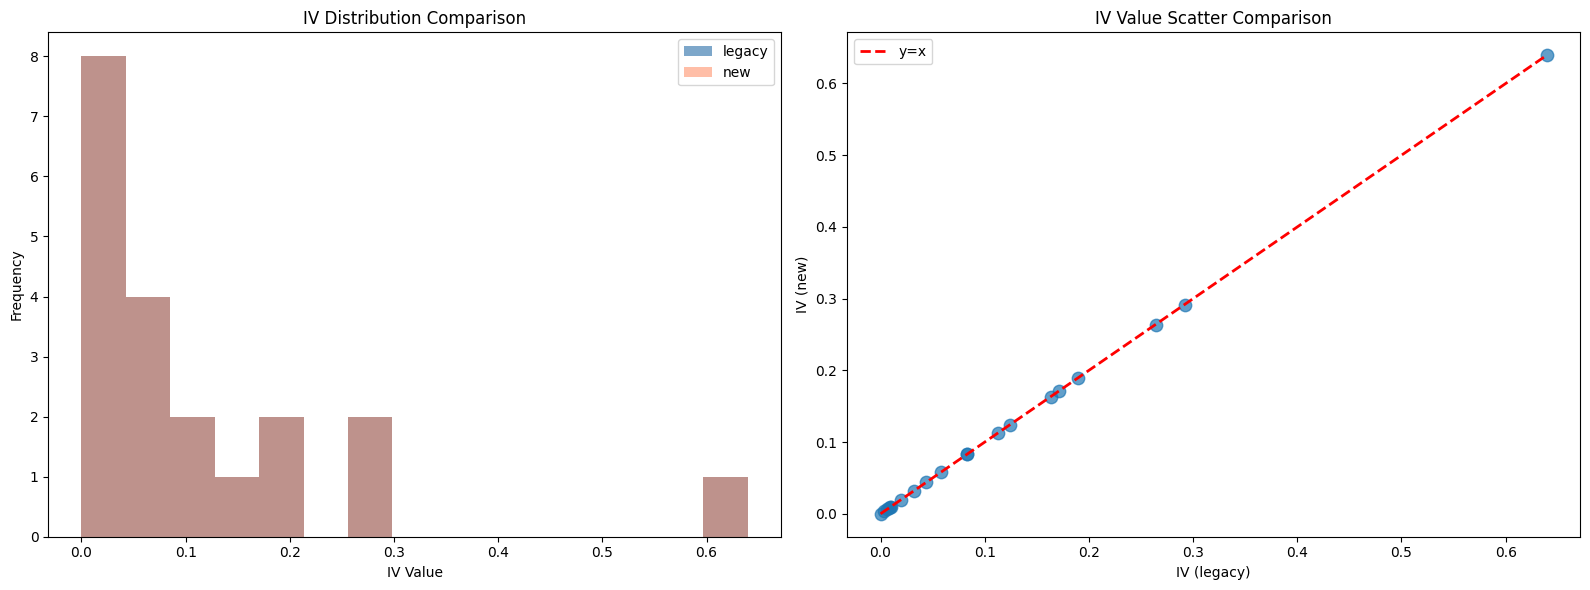

In [24]:
import matplotlib.pyplot as plt

def plot_iv_comparison(iv_df_legacy, iv_df_new):
    """绘制 IV 值对比图"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # IV 分布直方图
    ax1 = axes[0]
    ax1.hist(iv_df_legacy['IV'], bins=15, alpha=0.7, label='legacy', color='steelblue')
    ax1.hist(iv_df_new['IV'], bins=15, alpha=0.5, label='new', color='coral')
    ax1.set_xlabel('IV Value')
    ax1.set_ylabel('Frequency')
    ax1.set_title('IV Distribution Comparison')
    ax1.legend()
    
    # IV 散点对比图
    ax2 = axes[1]
    ax2.scatter(iv_df_legacy['IV'], iv_df_new['IV'], alpha=0.7, s=80)
    max_iv = max(iv_df_legacy['IV'].max(), iv_df_new['IV'].max())
    ax2.plot([0, max_iv], [0, max_iv], 'r--', label='y=x', linewidth=2)
    ax2.set_xlabel('IV (legacy)')
    ax2.set_ylabel('IV (new)')
    ax2.set_title('IV Value Scatter Comparison')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

plot_iv_comparison(iv_df_legacy, iv_df_new)

Top 6 变量 WOE 曲线对比:


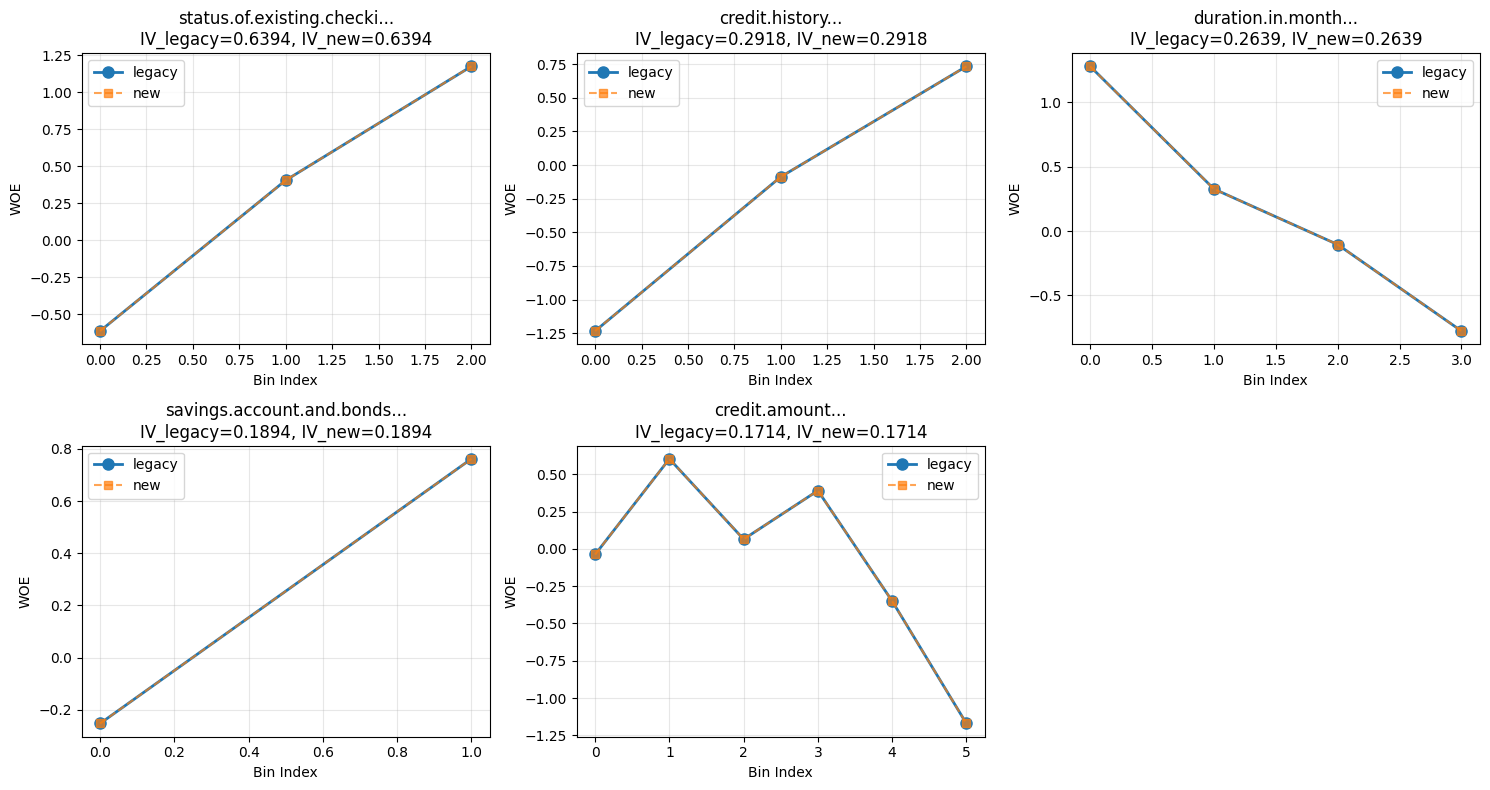

In [25]:
def plot_top_vars_woe(bins_legacy, bins_new, top_vars, n_cols=3):
    """绘制 Top 变量的 WOE 对比图"""
    n_vars = len(top_vars)
    n_rows = (n_vars + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_vars == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for idx, var in enumerate(top_vars):
        ax = axes[idx]
        
        # legacy
        df_leg = bins_legacy[var][~bins_legacy[var]['is_special_values']].copy()
        # new
        df_new = bins_new[var][~bins_new[var]['is_special_values']].copy()
        
        x_legacy = range(len(df_leg))
        x_new = range(len(df_new))
        
        ax.plot(x_legacy, df_leg['woe'].values, 'o-', label='legacy', markersize=8, linewidth=2)
        ax.plot(x_new, df_new['woe'].values, 's--', label='new', markersize=6, linewidth=1.5, alpha=0.7)
        
        ax.set_xlabel('Bin Index')
        ax.set_ylabel('WOE')
        ax.set_title(f'{var[:25]}...\nIV_legacy={df_leg["total_iv"].iloc[0]:.4f}, IV_new={df_new["total_iv"].iloc[0]:.4f}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # 隐藏多余的子图
    for idx in range(len(top_vars), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

print("Top 6 变量 WOE 曲线对比:")
plot_top_vars_woe(bins_legacy, bins_new, top_vars[:6])

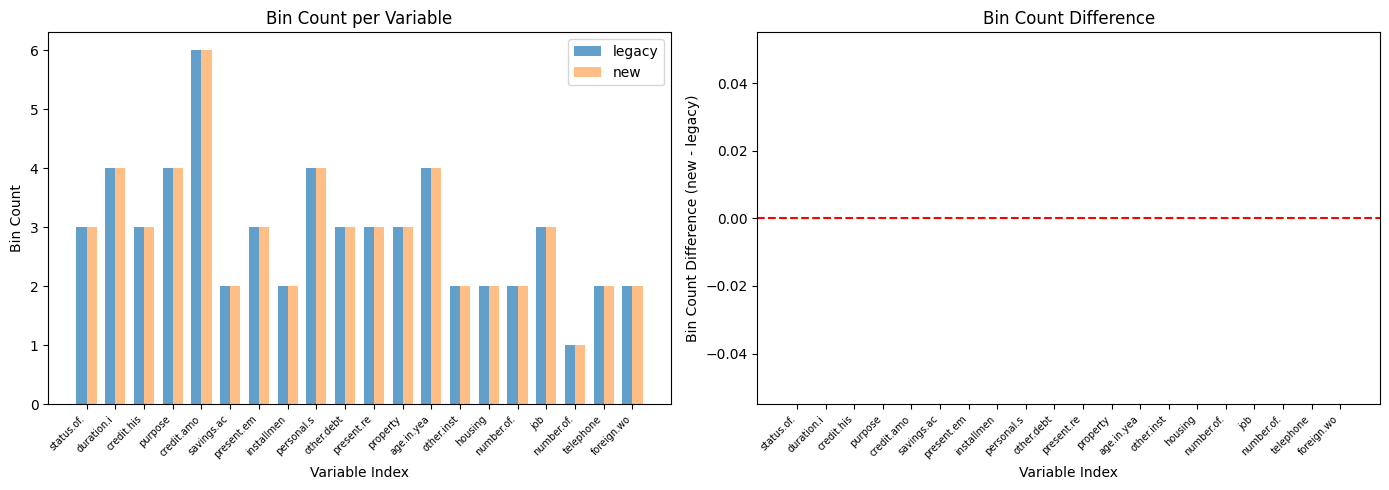

In [26]:
# 分箱数量分布对比
def plot_bin_count_comparison(bin_count_compare):
    """绘制分箱数量对比"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 分箱数量分布
    ax1 = axes[0]
    x = range(len(bin_count_compare))
    width = 0.35
    ax1.bar([i - width/2 for i in x], bin_count_compare['bins_legacy'], width, alpha=0.7, label='legacy')
    ax1.bar([i + width/2 for i in x], bin_count_compare['bins_new'], width, alpha=0.5, label='new')
    ax1.set_xlabel('Variable Index')
    ax1.set_ylabel('Bin Count')
    ax1.set_title('Bin Count per Variable')
    ax1.legend()
    ax1.set_xticks(x)
    ax1.set_xticklabels([v[:10] for v in bin_count_compare['variable']], rotation=45, ha='right', fontsize=7)
    
    # 分箱数量差异
    ax2 = axes[1]
    ax2.bar(x, bin_count_compare['bins_diff'])
    ax2.axhline(y=0, color='r', linestyle='--')
    ax2.set_xlabel('Variable Index')
    ax2.set_ylabel('Bin Count Difference (new - legacy)')
    ax2.set_title('Bin Count Difference')
    ax2.set_xticks(x)
    ax2.set_xticklabels([v[:10] for v in bin_count_compare['variable']], rotation=45, ha='right', fontsize=7)
    
    plt.tight_layout()
    plt.show()

plot_bin_count_comparison(bin_count_compare)

## 8. 总结

In [27]:
print("="*70)
print(" "*20 + "German Credit 分箱对比总结")
print("="*70)

print(f"\n数据集: germancredit.csv")
print(f"样本数: {len(df):,}")
print(f"特征数: {len(all_features)} (数值型: {len(numeric_vars)}, 类别型: {len(categorical_vars)})")

print("\n" + "-"*70)
print("1. 性能对比")
print("-"*70)
print(f"   scorecard_legacy 耗时: {legacy_time:.2f} 秒")
print(f"   scorecard 模块耗时:   {new_time:.2f} 秒")
print(f"   性能差异: {(new_time - legacy_time):.2f} 秒 ({(new_time/legacy_time - 1)*100:+.1f}%)")

print("\n" + "-"*70)
print("2. IV 值对比")
print("-"*70)
print(f"   平均差异: {iv_compare['IV_diff'].mean():.6f}")
print(f"   最大差异: {iv_compare['IV_diff'].max():.6f}")
print(f"   差异 > 0.001 的变量数: {(iv_compare['IV_diff'] > 0.001).sum()} / {len(all_features)}")
print(f"   差异 > 0.01 的变量数: {(iv_compare['IV_diff'] > 0.01).sum()} / {len(all_features)}")

print("\n" + "-"*70)
print("3. 分箱数量对比")
print("-"*70)
print(f"   legacy 总分箱数: {bin_count_compare['bins_legacy'].sum()}")
print(f"   new 总分箱数: {bin_count_compare['bins_new'].sum()}")
print(f"   分箱数完全一致的变量: {(bin_count_compare['bins_diff'] == 0).sum()} / {len(all_features)}")

print("\n" + "-"*70)
print("4. 切分点对比")
print("-"*70)
print(f"   切分点完全一致的变量: {breaks_df['is_same'].sum()} / {len(all_features)}")

print("\n" + "-"*70)
print("5. WOE 值对比")
print("-"*70)
print(f"   平均最大差异: {woe_diff_df['max_woe_diff'].mean():.6f}")
print(f"   最大差异: {woe_diff_df['max_woe_diff'].max():.6f}")

print("\n" + "-"*70)
print("6. 结论")
print("-"*70)
if iv_compare['IV_diff'].max() < 0.01:
    print("   ✓ scorecard 模块与 scorecard_legacy 模块分箱结果高度一致")
    print("   ✓ 两个模块可以互换使用，结果差异在可接受范围内")
else:
    print("   ⚠ 两个模块分箱结果存在一定差异，需要进一步检查")
    print("   ⚠ 建议查看差异较大的变量的分箱详情")

print("\n" + "-"*70)
print("7. German Credit 数据集特点")
print("-"*70)
print("   - 样本量较小 (1000 条)")
print("   - 混合数值型和类别型变量")
print("   - 类别型变量较多，需要特别关注分箱合并")
print("   - IV 值整体较低，变量区分能力有限")

                    German Credit 分箱对比总结

数据集: germancredit.csv
样本数: 1,000
特征数: 20 (数值型: 7, 类别型: 13)

----------------------------------------------------------------------
1. 性能对比
----------------------------------------------------------------------
   scorecard_legacy 耗时: 1.14 秒
   scorecard 模块耗时:   1.35 秒
   性能差异: 0.21 秒 (+18.2%)

----------------------------------------------------------------------
2. IV 值对比
----------------------------------------------------------------------
   平均差异: 0.000000
   最大差异: 0.000000
   差异 > 0.001 的变量数: 0 / 20
   差异 > 0.01 的变量数: 0 / 20

----------------------------------------------------------------------
3. 分箱数量对比
----------------------------------------------------------------------
   legacy 总分箱数: 58
   new 总分箱数: 58
   分箱数完全一致的变量: 20 / 20

----------------------------------------------------------------------
4. 切分点对比
----------------------------------------------------------------------
   切分点完全一致的变量: 20 / 20

-----------------------------------